In [ ]:
import pandas as pd

df = pd.read_csv("/content/amazon_ecommerce_combined.csv")

df.head()

,product,price,rating,rating_count,url,category
0,Samsung 108 cm (43 inches) Crystal 4K Series U...,"38,990",4.3,"2,271",https://www.amazon.in//gp/slredirect/picassoRe...,Tvs
1,Samsung 108 cm (43 Inches) Wondertainment Seri...,"32,990",4.3,"8,938",https://www.amazon.in//gp/slredirect/picassoRe...,Tvs
2,Mi 80 cm (32 inches) HD Ready Android Smart LE...,"16,999",4.3,"54,996",https://www.amazon.in//gp/bestsellers/electron...,Tvs
3,eAirtec 61 cms (24 inches) HD Ready LED TV 24D...,"7,850",4.0,"5,257",https://www.amazon.in//gp/bestsellers/electron...,Tvs
4,LG 80 cm (32 inches) HD Ready Smart LED TV 32L...,"17,999",4.3,"10,898",https://www.amazon.in//LG-inches-Ready-Smart-3...,Tvs


In [ ]:
print(df.shape)

(1574, 6)


In [ ]:
print(df.columns)

Index(['product', 'price', 'rating', 'rating_count', 'url', 'category'], dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1574 entries, 0 to 1573
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       1574 non-null   object 
 1   price         1574 non-null   object 
 2   rating        1574 non-null   float64
 3   rating_count  1574 non-null   object 
 4   url           1574 non-null   object 
 5   category      1574 non-null   object 
dtypes: float64(1), object(5)
memory usage: 73.9+ KB


In [ ]:
df.isnull().sum()

,0
product,0
price,0
rating,0
rating_count,0
url,0
category,0


In [ ]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 1481


In [ ]:

price_stats = df['price'].str.replace(',', '').astype(float).agg(["mean", "median", "min", "max", "count"])

print(price_stats)

mean      30983.735989
median    29999.000000
min        6999.000000
max       91499.000000
count      1481.000000
Name: price, dtype: float64


In [ ]:

df['price'] = df['price'].str.replace(',', '').astype(float)
category_price = df.groupby('category')['price'].mean()

print(category_price)

category
Laptops    39047.801598
Mobiles    15862.582090
Tvs        26646.844156
Name: price, dtype: float64


/tmp/ipykernel_573/1681124417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].str.replace(',', '').astype(float)


In [ ]:
rating_review = df[['product', 'rating', 'rating_count']]

print(rating_review.head())

                                             product  rating rating_count
0  Samsung 108 cm (43 inches) Crystal 4K Series U...     4.3        2,271
1  Samsung 108 cm (43 Inches) Wondertainment Seri...     4.3        8,938
2  Mi 80 cm (32 inches) HD Ready Android Smart LE...     4.3       54,996
3  eAirtec 61 cms (24 inches) HD Ready LED TV 24D...     4.0        5,257
4  LG 80 cm (32 inches) HD Ready Smart LED TV 32L...     4.3       10,898


In [ ]:
df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)

/tmp/ipykernel_573/1911997257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rating_count'] = df['rating_count'].str.replace(',', '').astype(float)


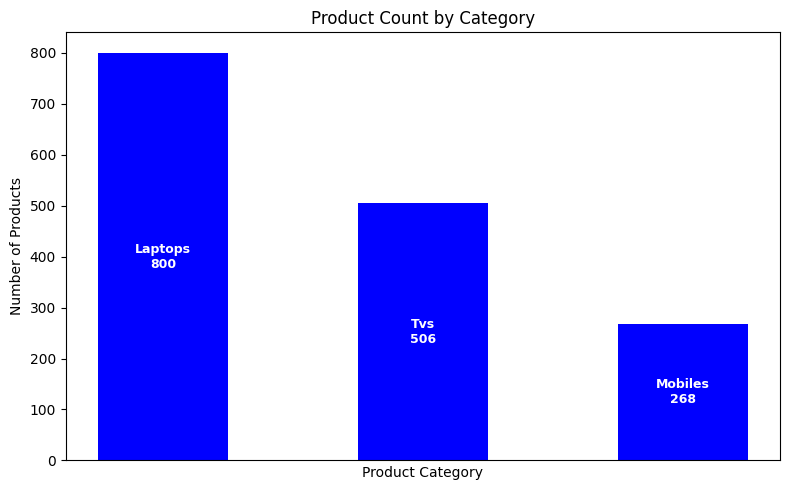

In [ ]:
import matplotlib.pyplot as plt

category_count = df['category'].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    category_count.index,
    category_count.values,
    color='blue',
    width=0.5
)

plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.title('Product Count by Category')

# Category name + count inside blue bar
for bar, category in zip(bars, category_count.index):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{category}\n{int(bar.get_height())}',
        ha='center',
        va='center',
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks([])
plt.tight_layout()
plt.show()

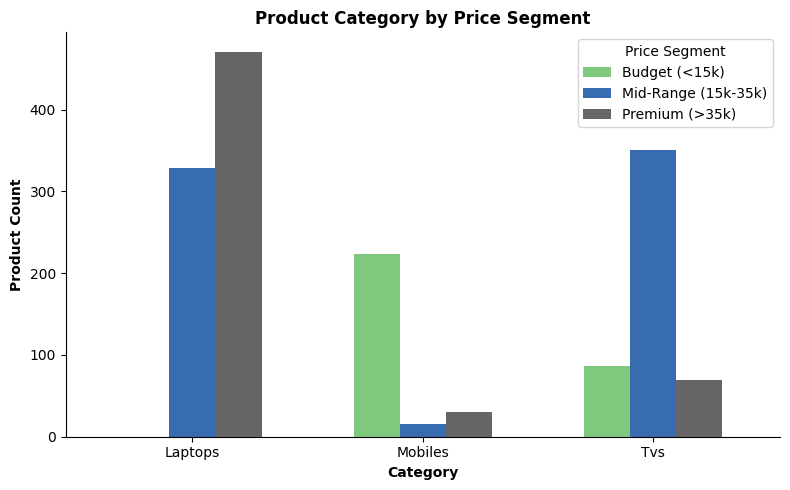

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Price Bins Create Panrom
df['price_group'] = pd.cut(
    df['price'],
    bins=[0, 15000, 35000, float('inf')],
    labels=['Budget (<15k)', 'Mid-Range (15k-35k)', 'Premium (>35k)']
)

# Cross Tabulation
ct = pd.crosstab(df['category'], df['price_group'])

# Grouped Bar Plot
ax = ct.plot(kind='bar', figsize=(8, 5), width=0.6, colormap='Accent')

plt.title('Product Category by Price Segment', fontweight='bold', fontsize=12)
plt.xlabel('Category', fontweight='bold')
plt.ylabel('Product Count', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Price Segment')

# Clean Borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

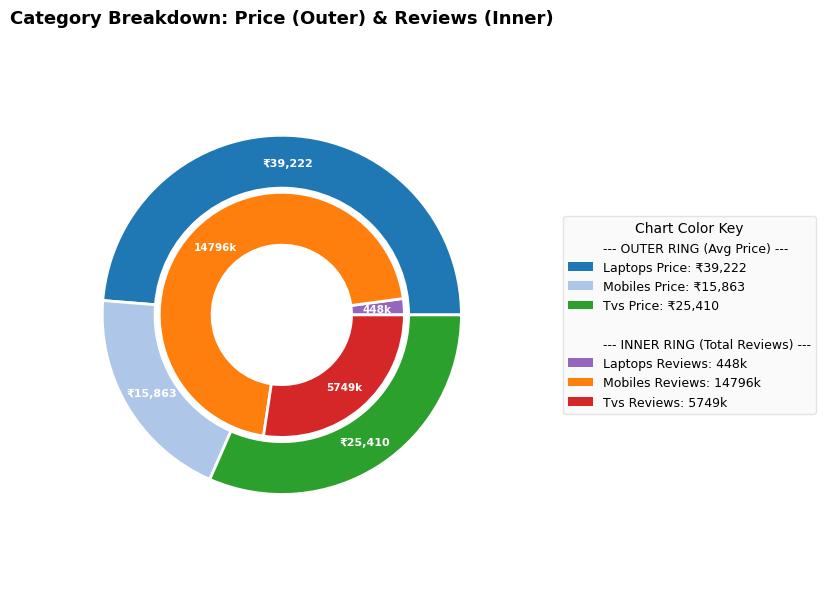

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# 1. Clean rating_count
df['rating_count'] = (
    df['rating_count']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
    .astype(float)
)

# 2. Category Aggregation
d = (
    df.groupby('category')
    .agg(
        total_reviews=('rating_count', 'sum'),
        avg_price=('price', 'mean'),
    )
    .reset_index()
)

# Outer Ring Colors (Price - Blue Palette)
outer_colors = ['#1f77b4', '#aec7e8', '#2ca02c']

# Inner Ring Colors (Reviews - Purple/Orange Palette)
inner_colors = ['#9467bd', '#ff7f0e', '#d62728']

# Figure Setup
fig, ax = plt.subplots(figsize=(10, 6))

# Outer Ring - Average Price
wedges_outer, _ = ax.pie(
    d['avg_price'],
    radius=0.85,
    colors=outer_colors,
    wedgeprops=dict(width=0.25, edgecolor='white', linewidth=2),
)

# Inner Ring - Total Reviews
wedges_inner, _ = ax.pie(
    d['total_reviews'],
    radius=0.58,
    colors=inner_colors,
    wedgeprops=dict(width=0.25, edgecolor='white', linewidth=2),
)

# Outer Ring Labels
for wedge, category, price in zip(wedges_outer, d['category'], d['avg_price']):
  angle = (wedge.theta1 + wedge.theta2) / 2
  x = 0.72 * np.cos(np.radians(angle))
  y = 0.72 * np.sin(np.radians(angle))
  ax.text(
      x,
      y,
      f'₹{price:,.0f}',
      ha='center',
      va='center',
      fontsize=8,
      fontweight='bold',
      color='white',
  )

# Inner Ring Labels
for wedge, reviews in zip(wedges_inner, d['total_reviews']):
  angle = (wedge.theta1 + wedge.theta2) / 2
  x = 0.45 * np.cos(np.radians(angle))
  y = 0.45 * np.sin(np.radians(angle))
  ax.text(
      x,
      y,
      f'{int(reviews/1000)}k',
      ha='center',
      va='center',
      fontsize=7.5,
      fontweight='bold',
      color='white',
  )

plt.title(
    'Category Breakdown: Price (Outer) & Reviews (Inner)',
    fontweight='bold',
    fontsize=13,
    pad=20,
)

# --- LEGENDS (Matching Inner & Outer Colors) ---
legend_handles = [
    Patch(color='none', label='--- OUTER RING (Avg Price) ---')
]

for cat, price, color in zip(d['category'], d['avg_price'], outer_colors):
  legend_handles.append(
      Patch(facecolor=color, label=f'{cat} Price: ₹{price:,.0f}')
  )

legend_handles.append(Patch(color='none', label=''))  # Empty Line

legend_handles.append(
    Patch(color='none', label='--- INNER RING (Total Reviews) ---')
)

for cat, reviews, color in zip(d['category'], d['total_reviews'], inner_colors):
  legend_handles.append(
      Patch(facecolor=color, label=f'{cat} Reviews: {int(reviews/1000)}k')
  )

# Side Legend Placement
ax.legend(
    handles=legend_handles,
    title='Chart Color Key',
    title_fontsize='10',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    facecolor='#f9f9f9',
    edgecolor='#dddddd',
    fontsize=9,
)

plt.tight_layout()
plt.show()

In [ ]:
# Products with high ratings

high_rating = df[df['rating'] >= 4.5][['product', 'rating']]

print("Products with High Ratings:")
print(high_rating)

Products with High Ratings:
                                                product  rating
10    Samsung 138 cm (55 Inches) Wondertainment Seri...     4.5
11    Sony Bravia 80 cm (32 inches) HD Ready Smart A...     4.7
23    Samsung 138 cm (55 Inches) Wondertainment Seri...     4.5
32    Sony Bravia 80 cm (32 inches) HD Ready Smart A...     4.7
45    Samsung 138 cm (55 Inches) Wondertainment Seri...     4.5
...                                                 ...     ...
1457  (Renewed) HP ProBook 640 G1 14-inch Laptop (Co...     5.0
1482  (Renewed) HP ProBook 640 G1 14-inch Laptop (Co...     5.0
1507  (Renewed) HP ProBook 640 G1 14-inch Laptop (Co...     5.0
1532  (Renewed) HP ProBook 640 G1 14-inch Laptop (Co...     5.0
1557  (Renewed) HP ProBook 640 G1 14-inch Laptop (Co...     5.0

[98 rows x 2 columns]


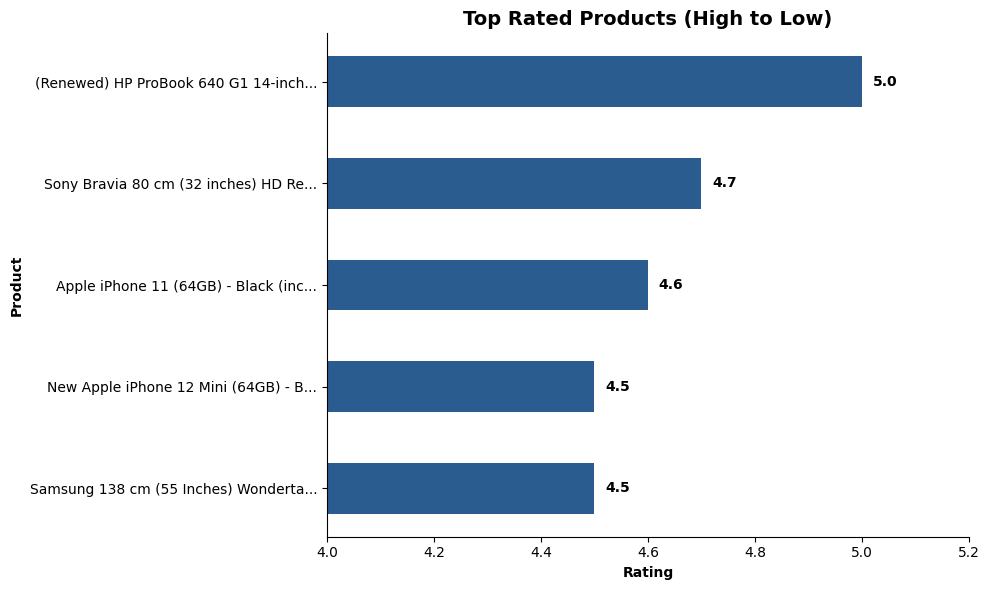

In [ ]:
import matplotlib.pyplot as plt

# Drop duplicates & filter products with rating >= 4.5
high_rating = df[df['rating'] >= 4.5][['product', 'rating']].drop_duplicates()

# Sort by rating ascending so that higher values render at the TOP of plt.barh
top_rating = high_rating.sort_values('rating', ascending=True).tail(10)

# Product names shortening
top_rating['product_short'] = top_rating['product'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_rating['product_short'],
    top_rating['rating'],
    color='#2b5c8f',
    height=0.5,
)

plt.xlabel('Rating', fontweight='bold')
plt.ylabel('Product', fontweight='bold')
plt.title('Top Rated Products (High to Low)', fontweight='bold', fontsize=14)

plt.xlim(4.0, 5.2)

# Display exact rating values next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
    )

# Clean borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

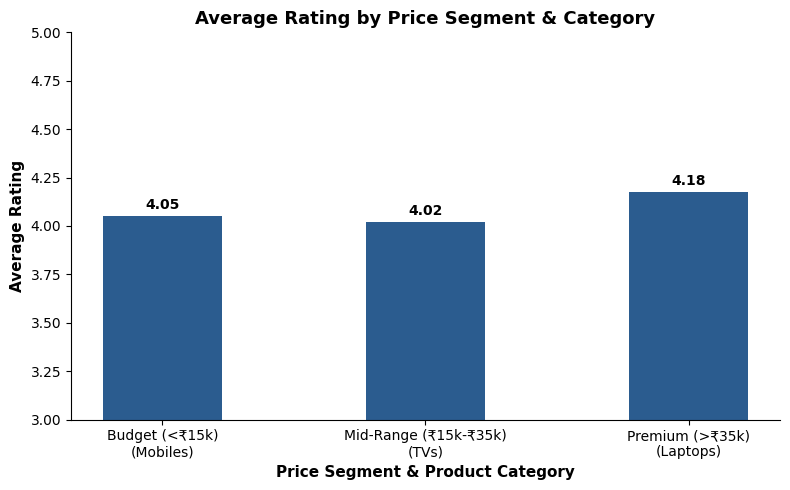

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Price Segments with Price Range + Categories
df["price_group"] = pd.cut(
    df["price"],
    bins=[0, 15000, 35000, float("inf")],
    labels=[
        "Budget (<₹15k)\n(Mobiles)",
        "Mid-Range (₹15k-₹35k)\n(TVs)",
        "Premium (>₹35k)\n(Laptops)",
    ],
)

# 2. Average rating calculate panna
avg_rating = (
    df.groupby("price_group", observed=False)["rating"].mean().reset_index()
)

# 3. Front/Vertical Bar Chart Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(
    avg_rating["price_group"],
    avg_rating["rating"],
    color="#2b5c8f",
    width=0.45,
)

# Values-a vertical bars mela print panna (Exact Rating High/Low)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Average Rating by Price Segment & Category",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("Price Segment & Product Category", fontweight="bold", fontsize=11)
plt.ylabel("Average Rating", fontweight="bold", fontsize=11)
plt.ylim(3.0, 5.0)  # High to Low differences clear-a theriya zoom-in

# Clean borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()